<a href="https://colab.research.google.com/github/Keistkmiya/Introduction-to-Machine-Learning-with-Python/blob/main/All_Chapter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Introduction
Pada bab ini, akan mempelajari konsep dasar Machine Learning melalui studi kasus klasifikasi bunga Iris.

### Library Utama:
- **scikit-learn**: Berisi algoritma machine learning yang akan digunakan.
- **NumPy & Pandas**: Untuk pengolahan data angka dan tabel.
- **Matplotlib**: Untuk visualisasi data.

In [50]:
import sys
import pandas as pd
import matplotlib
import numpy as np
import scipy as sp
import IPython
import sklearn

print(f"Versi scikit-learn: {sklearn.__version__}")

Versi scikit-learn: 1.6.1


### 1.1 Meet the Data
Saya akan menggunakan dataset Iris yang berisi data pengukuran mahkota (sepal) dan kelopak (petal) bunga Iris. Tujuan saya adalah mengklasifikasikan spesies bunga berdasarkan ukuran tersebut.

In [51]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

print("Kunci dalam iris_dataset:", iris_dataset.keys())
print("Target names (Spesies):", iris_dataset['target_names'])
print("Feature names (Fitur):", iris_dataset['feature_names'])

Kunci dalam iris_dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Target names (Spesies): ['setosa' 'versicolor' 'virginica']
Feature names (Fitur): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### 1.2 Training and Testing Data
Dalam Machine Learning, tidak boleh menguji model menggunakan data yang sama dengan data saat melatihnya. Mengapa? Karena model bisa saja hanya "menghafal" data tersebut (overfitting).

Saya membagi data menggunakan fungsi `train_test_split`:
- **Training Data**: 75% dari total data (digunakan untuk melatih model).
- **Testing Data**: 25% dari total data (digunakan untuk mengukur akurasi model).

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_test: {y_test.shape}")

Bentuk X_train: (112, 4)
Bentuk y_train: (112,)
Bentuk X_test: (38, 4)
Bentuk y_test: (38,)


### 1.3 Building Your First Model: k-Nearest Neighbors
Saya menggunakan algoritma k-NN dengan `n_neighbors=1`. Artinya, model akan memprediksi spesies bunga baru berdasarkan 1 tetangga yang paling mirip di dalam data training.

In [53]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

### 1.4 Evaluating the Model
Saya menggunakan data testing (`X_test`) untuk melihat apakah model bisa menebak dengan benar. Hasilnya disebut sebagai **Accuracy Score**.

In [54]:
y_pred = knn.predict(X_test)
print(f"Hasil Prediksi: \n{y_pred}")

print(f"Akurasi model: {knn.score(X_test, y_test):.2f}")

Hasil Prediksi: 
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Akurasi model: 0.97


# Chapter 2: Supervised Learning
Supervised Learning adalah tipe Machine Learning di mana kita memberikan model data beserta jawabannya (label). Tujuannya adalah agar model bisa belajar memetakan input ke output yang benar.

### Dua Tipe Utama:
1. **Classification (Klasifikasi)**: Memprediksi kategori (misal: spam atau bukan spam).
2. **Regression (Regresi)**: Memprediksi angka kontinu (misal: harga rumah atau suhu).

### Konsep Penting:
- **Generalization**: Kemampuan model memprediksi data baru yang belum pernah dilihat.
- **Overfitting**: Model terlalu hafal data latihan sehingga gagal memprediksi data baru.
- **Underfitting**: Model terlalu simpel sehingga tidak paham pola data.

In [55]:
!pip install mglearn

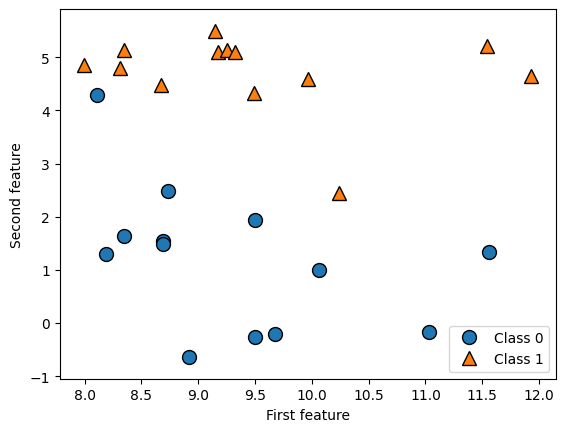

Bentuk data X: (26, 2)


In [56]:
import mglearn
import matplotlib.pyplot as plt
import numpy as np

X, y = mglearn.tools.make_handcrafted_dataset()

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

print(f"Bentuk data X: {X.shape}")

### 2.1 k-Nearest Neighbors Regression
Selain untuk klasifikasi, k-NN juga bisa digunakan untuk regresi. Di sini, Saya mencoba memprediksi nilai numerik kontinu.

**Cara Kerja:**
- Untuk `n_neighbors=1`, prediksi adalah nilai dari tetangga terdekat.
- Untuk `n_neighbors > 1`, prediksi adalah rata-rata (mean) dari nilai tetangga-tetangga terdekatnya.

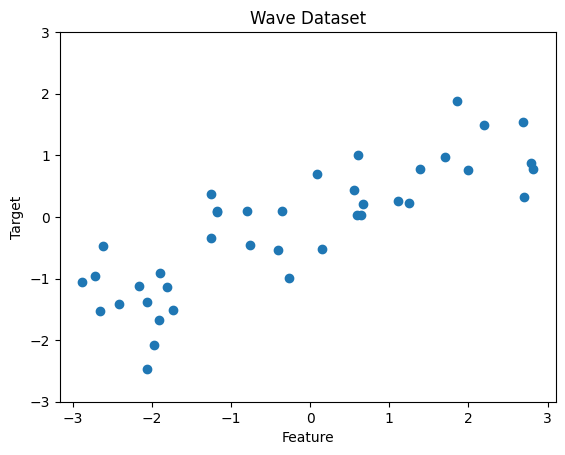

In [57]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X, y = mglearn.datasets.make_wave(n_samples=40)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Wave Dataset")
plt.show()

In [58]:
from sklearn.neighbors import KNeighborsRegressor

reg = KNeighborsRegressor(n_neighbors=3)

reg.fit(X_train, y_train)

print(f"Prediksi data testing:\n{reg.predict(X_test)}")

Prediksi data testing:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [59]:
print(f"Test set R^2: {reg.score(X_test, y_test):.2f}")

Test set R^2: 0.83


### 2.2 Analyzing KNeighborsRegressor
Untuk memahami pengaruh jumlah tetangga terhadap model, Saya akan membandingkan prediksi menggunakan 1, 3, dan 9 tetangga.

**Teori Penting:**
- **n_neighbors = 1**: Model sangat mengikuti data training secara detail. Garis prediksi akan terlihat sangat tajam dan tidak beraturan. Ini berisiko menyebabkan **Overfitting**.
- **n_neighbors = banyak (misal 9)**: Prediksi menjadi lebih halus (smooth) karena merupakan rata-rata dari banyak tetangga. Namun, model bisa menjadi terlalu simpel dan kehilangan detail penting, yang disebut **Underfitting**.

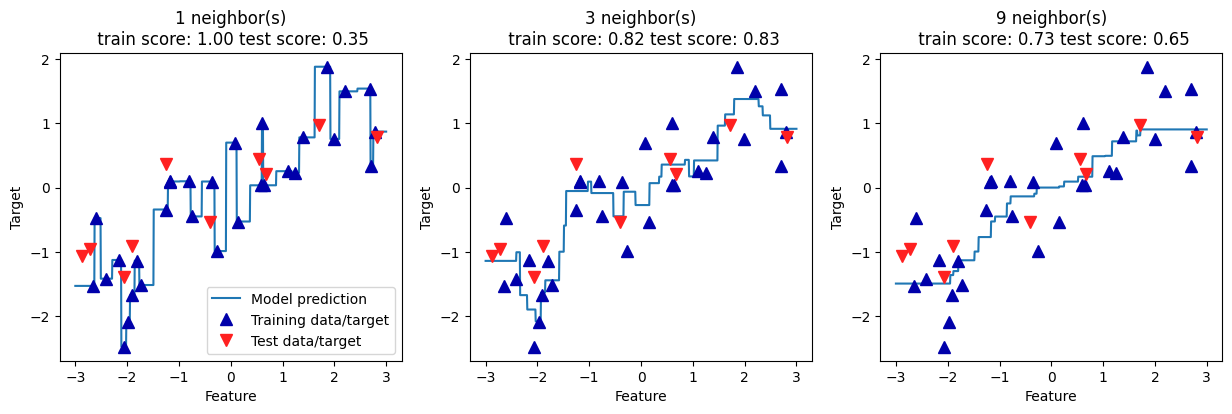

In [60]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

line = np.linspace(-3, 3, 1000).reshape(-1, 1)

for n_neighbors, ax in zip([1, 3, 9], axes):
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)

    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)

    ax.set_title(
        f"{n_neighbors} neighbor(s)\n train score: {reg.score(X_train, y_train):.2f} "
        f"test score: {reg.score(X_test, y_test):.2f}")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")

axes[0].legend(["Model prediction", "Training data/target", "Test data/target"], loc="best")

**Kesimpulan dari Grafik:**
1. Pada **1 neighbor**, skor training sangat sempurna (1.00), tapi garis predisinya sangat bergejolak. Ini adalah tanda model terlalu sensitif terhadap noise pada data.
2. Seiring bertambahnya **neighbors**, garis prediksi menjadi lebih stabil dan halus.
3. Skor terbaik biasanya ditemukan pada titik tengah yang seimbang, di mana model tidak terlalu kompleks tapi juga tidak terlalu sederhana.

## 2.3 Linear Models
Linear Models adalah kelompok algoritma yang membuat prediksi menggunakan fungsi linear dari fitur-fitur inputnya. Untuk regresi, prediksi dilakukan dengan mencari garis lurus (atau bidang pada dimensi tinggi) yang paling mendekati data.

Persamaan matematis untuk model linear adalah:
$$y = w[0] \cdot x[0] + w[1] \cdot x[1] + ... + w[p] \cdot x[p] + b$$

**Keterangan:**
- $x[0]$ hingga $x[p]$ adalah fitur-fitur dari satu titik data.
- $w$ (weights) dan $b$ (bias) adalah parameter model yang dipelajari.
- $y$ adalah prediksi yang dihasilkan.

w[0]: 0.393906  b: -0.031804


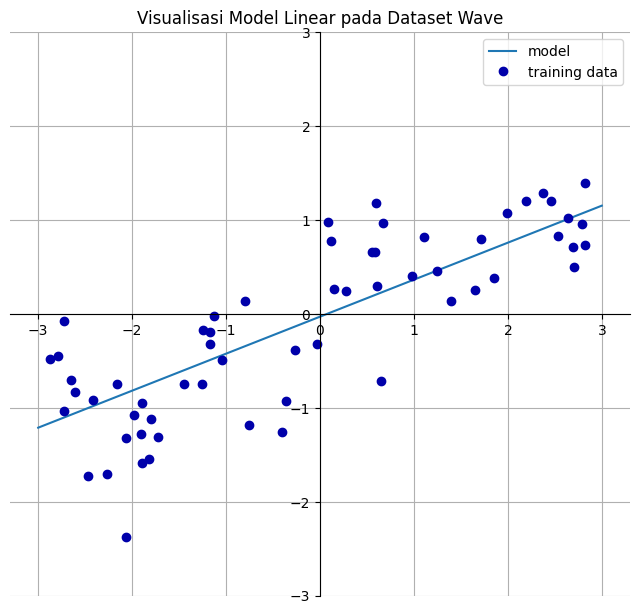

In [61]:
import mglearn
import matplotlib.pyplot as plt

mglearn.plots.plot_linear_regression_wave()
plt.title("Visualisasi Model Linear pada Dataset Wave")
plt.show()

## 2.4 Linear Regression (Ordinary Least Squares)
Linear Regression atau *Ordinary Least Squares* (OLS) adalah metode linear paling sederhana untuk regresi.

**Teori Singkat:**
Model ini mencari nilai parameter $w$ dan $b$ yang meminimalkan **Mean Squared Error (MSE)**, yaitu rata-rata kuadrat selisih antara nilai prediksi dengan nilai target yang sebenarnya pada data training. OLS tidak memiliki parameter tambahan (*hyperparameters*) untuk mengontrol kompleksitas model.

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import mglearn

X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)

print(f"lr.coef_ (bobot/w): {lr.coef_}")
print(f"lr.intercept_ (bias/b): {lr.intercept_}")

lr.coef_ (bobot/w): [0.39390555]
lr.intercept_ (bias/b): -0.031804343026759746


## 2.5 Evaluating Linear Regression Performance
Setelah melatih model, perlu mengevaluasi seberapa baik model tersebut bekerja pada data yang sudah dilihat (training) dan data baru (testing).

**Kriteria Evaluasi:**
- Saya menggunakan skor $R^2$ (Koefisien Determinasi) yang berkisar antara 0 hingga 1.
- Jika skor training dan testing sama-sama rendah, itu tandanya model mengalami **Underfitting**.

In [63]:
print(f"Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Test set score: {lr.score(X_test, y_test):.2f}")

Training set score: 0.67
Test set score: 0.66


**Hasil Analisis:**
Pada dataset 'wave', Saya mendapatkan skor sekitar 0.67 pada training set dan 0.66 pada test set. Karena skor ini cukup rendah namun jarak antara keduanya sangat dekat, Saya bisa menyimpulkan bahwa model ini mengalami **Underfitting**, bukan Overfitting. Hal ini wajar karena dataset ini sangat sederhana (hanya satu fitur).

## 2.6 Ridge Regression
Ridge Regression juga merupakan model linear untuk regresi, namun dengan tambahan aturan khusus yang disebut **Regularization**.

**Teori Singkat:**
- **L2 Regularization**: Ridge menambahkan penalti pada besarnya koefisien ($w$). Tujuannya adalah membuat semua koefisien sekecil mungkin (mendekati nol).
- **Mengapa?**: Agar setiap fitur memiliki pengaruh yang kecil terhadap hasil prediksi. Ini membantu mencegah model menjadi terlalu kompleks dan mengalami **Overfitting**.
- **Parameter Alpha ($\alpha$)**: Ini adalah tombol kendali.
    - Semakin besar $\alpha$, semakin besar penaltinya (koefisien semakin kecil/simpel).
    - Semakin kecil $\alpha$, model semakin mendekati Linear Regression biasa.

In [64]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import mglearn

X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [65]:
lr = LinearRegression().fit(X_train, y_train)
print("--- Linear Regression ---")
print(f"Training score: {lr.score(X_train, y_train):.2f}")
print(f"Test score: {lr.score(X_test, y_test):.2f}\n")

ridge = Ridge().fit(X_train, y_train)
print("--- Ridge Regression (alpha=1) ---")
print(f"Training score: {ridge.score(X_train, y_train):.2f}")
print(f"Test score: {ridge.score(X_test, y_test):.2f}")

--- Linear Regression ---
Training score: 0.95
Test score: 0.61

--- Ridge Regression (alpha=1) ---
Training score: 0.89
Test score: 0.75


## 2.7 Pengaruh Alpha terhadap Koefisien Model
Parameter **Alpha** adalah cara Saya mengontrol kompleksitas model Ridge.

**Analisis Teori:**
- **Alpha tinggi (misal 10)**: Memaksa koefisien ($w$) menjadi sangat kecil (mendekati nol). Model menjadi sangat simpel tapi aman dari overfitting.
- **Alpha rendah (misal 0.1)**: Membiarkan koefisien menjadi lebih besar. Model menjadi lebih kompleks dan perilakunya mulai menyerupai Linear Regression biasa.

In [66]:
ridge10 = Ridge(alpha=10).fit(X_train, y_train)

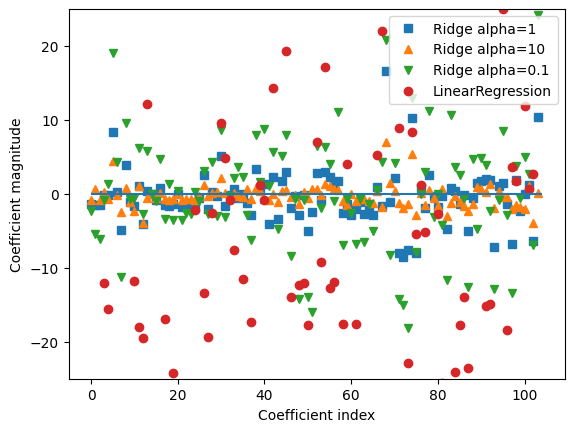

In [67]:
ridge = Ridge(alpha=1).fit(X_train, y_train) # Alpha default
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)

plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.plot(lr.coef_, 'o', label="LinearRegression")

plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()
plt.show()

## 2.8 Lasso Regression
Lasso (*Least Absolute Shrinkage and Selection Operator*) adalah jenis model linear lainnya yang menggunakan regularisasi untuk mencegah overfitting.

**Teori Singkat (Pendalaman):**
- **L1 Regularization**: Berbeda dengan Ridge yang menggunakan penalti kuadrat (L2), Lasso menggunakan penalti nilai absolut dari koefisien: $\alpha \sum |w_j|$.
- **Otomatis Seleksi Fitur**: Salah satu sifat paling penting dari Lasso adalah ia mampu memaksa koefisien fitur yang tidak penting menjadi **benar-benar nol**.
- **Kegunaan**: Sangat efektif digunakan jika kita memiliki ribuan fitur, namun Saya menduga hanya sedikit fitur yang benar-benar berpengaruh terhadap hasil.

In [68]:
from sklearn.linear_model import Lasso
import numpy as np

lasso = Lasso().fit(X_train, y_train)

print("--- Lasso dengan alpha=1.0 ---")
print(f"Training set score: {lasso.score(X_train, y_train):.2f}")
print(f"Test set score: {lasso.score(X_test, y_test):.2f}")
print(f"Jumlah fitur yang digunakan: {np.sum(lasso.coef_ != 0)}")

--- Lasso dengan alpha=1.0 ---
Training set score: 0.29
Test set score: 0.21
Jumlah fitur yang digunakan: 4


## 2.9 Mengatur Alpha pada Lasso
Jika Lasso dengan `alpha=1.0` memberikan hasil yang buruk (skor rendah di training dan test), itu artinya model mengalami **Underfitting**. Kita perlu menurunkan nilai `alpha` agar model lebih fleksibel.

In [69]:
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)

print("--- Lasso dengan alpha=0.01 ---")
print(f"Training set score: {lasso001.score(X_train, y_train):.2f}")
print(f"Test set score: {lasso001.score(X_test, y_test):.2f}")
print(f"Jumlah fitur yang digunakan: {np.sum(lasso001.coef_ != 0)}")

--- Lasso dengan alpha=0.01 ---
Training set score: 0.90
Test set score: 0.77
Jumlah fitur yang digunakan: 33


## 2.10 Linear Models for Classification
Meskipun namanya mengandung kata "Regression", **Logistic Regression** sebenarnya adalah algoritma klasifikasi. Bersama dengan **Linear Support Vector Machines (Linear SVC)**, keduanya merupakan pondasi dasar untuk model klasifikasi linear.

**Konsep Utama:**
- Keduanya mencari garis (pada 2D) atau bidang (pada dimensi tinggi) yang paling baik dalam memisahkan kelas-kelas data.
- Keputusan dibuat berdasarkan apakah sebuah data berada di "sisi kanan" atau "sisi kiri" dari garis pemisah tersebut.

Text(0, 0.5, 'Feature 1')

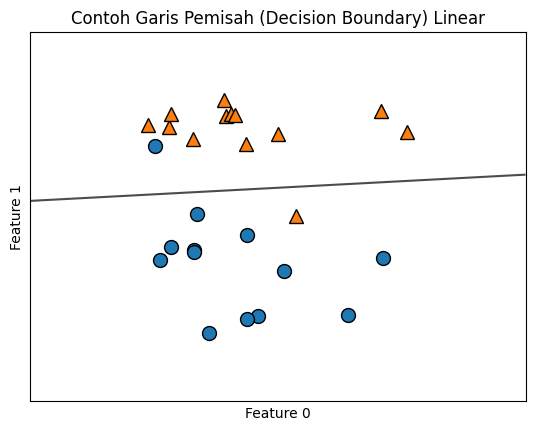

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import mglearn
import matplotlib.pyplot as plt

X, y = mglearn.datasets.make_forge()

mglearn.plots.plot_2d_separator(LinearSVC().fit(X, y), X, fill=False, alpha=.7)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.title("Contoh Garis Pemisah (Decision Boundary) Linear")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

## 2.11 Logistic Regression vs. Linear SVC
Walaupun tujuannya sama, yaitu klasifikasi, keduanya memiliki pendekatan matematis yang berbeda dalam menentukan garis pemisah.

**Perbedaan Singkat:**
- **Logistic Regression**: Menggunakan fungsi logistik untuk memprediksi probabilitas suatu kelas.
- **Linear SVC**: Berusaha memaksimalkan "jarak" (margin) antara garis pemisah dengan titik-titik data terdekat dari setiap kelas.
- Secara default, keduanya menggunakan **L2 Regularization**, sama seperti Ridge Regression.

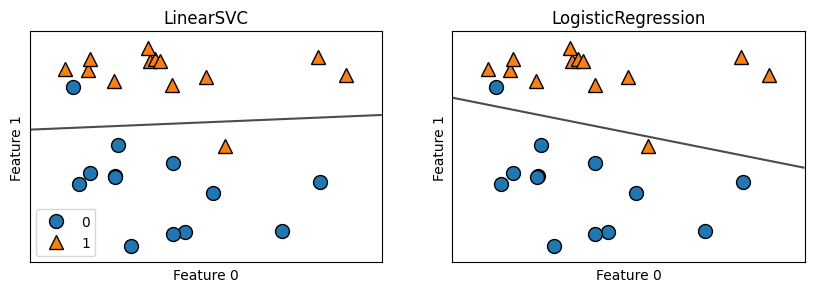

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for model, ax in zip([LinearSVC(max_iter=10000), LogisticRegression()], axes):
    clf = model.fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=False, eps=0.5, ax=ax, alpha=.7)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title(clf.__class__.__name__)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

axes[0].legend()

## 2.12 Pengaruh Parameter C
Pada model klasifikasi linear, parameter **C** berfungsi sebagai pengatur regularisasi.

**Analisis Parameter:**
- **C Kecil (misal 0.01)**: Regularisasi kuat. Model mencoba menyesuaikan dengan mayoritas data dan mengabaikan beberapa titik data yang menyimpang (mencegah overfitting).
- **C Besar (misal 1000)**: Regularisasi lemah. Model berusaha sangat keras untuk mengklasifikasikan setiap titik data training dengan benar, yang bisa membuat garis pemisah menjadi sangat kompleks (berisiko overfitting).

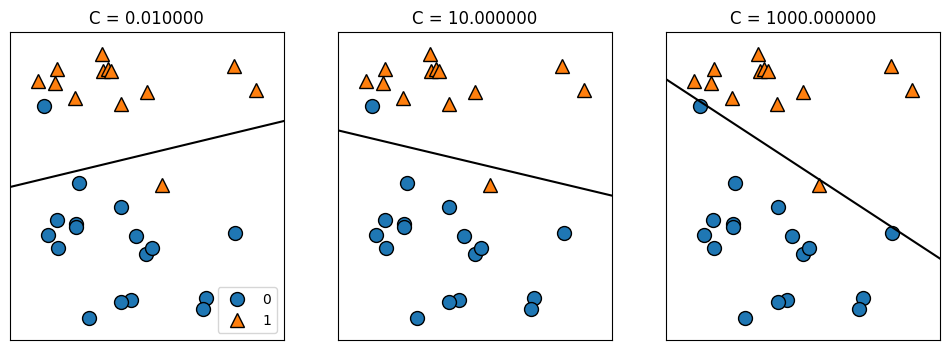

In [72]:
mglearn.plots.plot_linear_svc_regularization()

## 2.13 Linear Models for Multiclass Classification
Banyak model klasifikasi linear sebenarnya hanya dirancang untuk klasifikasi biner (dua kelas). Untuk menangani banyak kelas, teknik yang paling umum digunakan adalah **One-vs.-Rest (OvR)**.

**Cara Kerja OvR:**
- Sebuah model biner dibuat untuk setiap kelas yang ada.
- Setiap model mencoba membedakan satu kelas tertentu dari kelas-kelas lainnya.
- Saat prediksi, kelas yang memiliki skor tertinggi dari model binernya akan dipilih sebagai hasil akhir.

## 2.14 Implementasi Multiclass pada Dataset Blobs
Saya akan menerapkan `LinearSVC` pada dataset buatan bernama `blobs` yang memiliki tiga kelas berbeda untuk melihat bagaimana koefisien model bekerja pada kasus multiclass.

In [73]:
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC
import mglearn

X, y = make_blobs(random_state=42)

linear_svc = LinearSVC().fit(X, y)

print("Bentuk koefisien (Coefficients shape): ", linear_svc.coef_.shape)
print("Bentuk intercept (Intercept shape): ", linear_svc.intercept_.shape)

Bentuk koefisien (Coefficients shape):  (3, 2)
Bentuk intercept (Intercept shape):  (3,)


## 2.15 Visualisasi Keputusan Multiclass
Setelah model dilatih, Saya memvisualisasikan garis keputusan untuk masing-masing dari ketiga pengklasifikasi biner tersebut.

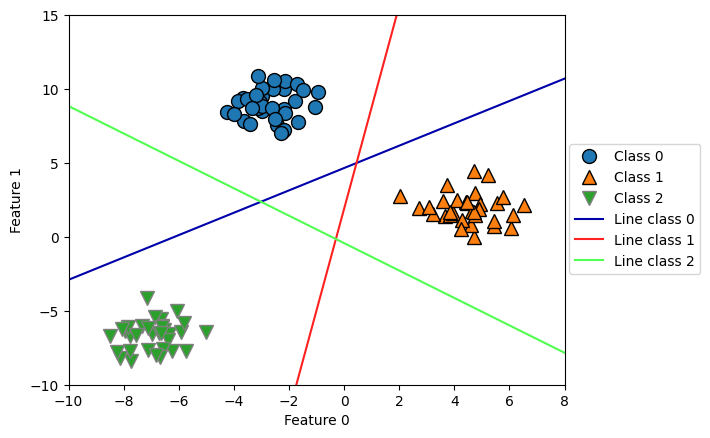

In [74]:
import matplotlib.pyplot as plt
import numpy as np

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
line = np.linspace(-15, 15)

for coef, intercept, color in zip(linear_svc.coef_, linear_svc.intercept_,
                                  mglearn.cm3.colors):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)

plt.ylim(-10, 15)
plt.xlim(-10, 8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1',
            'Line class 2'], loc=(1.01, 0.3))
plt.show()

## 2.16 Kelebihan dan Kekurangan Model Linear
**Kelebihan:**
- Sangat cepat untuk data besar.
- Cocok untuk data dengan fitur yang sangat banyak (sparse data).
- Mudah dipahami melalui nilai koefisien.

**Kekurangan:**
- Terbatas pada pola data yang linear (garis lurus).
- Performa bisa buruk pada data dengan fitur yang saling berinteraksi secara kompleks.

## 2.17 Naive Bayes Classifiers
Naive Bayes adalah kelompok pengklasifikasi yang sangat cepat dan sederhana. Mereka bekerja dengan menghitung probabilitas setiap fitur secara independen.

**Tipe Utama di scikit-learn:**
1. **GaussianNB**: Untuk data kontinu (seperti tinggi badan).
2. **BernoulliNB**: Untuk data biner (0 atau 1, seperti keberadaan kata dalam email).
3. **MultinomialNB**: Untuk data diskrit (seperti jumlah kemunculan kata).

In [75]:
from sklearn.naive_bayes import BernoulliNB
import numpy as np

# Contoh data biner sederhana
X = np.array([[0, 1, 0, 1],
              [1, 0, 1, 1],
              [0, 0, 0, 1],
              [1, 0, 1, 0]])
y = np.array([0, 1, 0, 1])

# Melatih model BernoulliNB
nb = BernoulliNB().fit(X, y)
print(f"Prediksi untuk data baru: {nb.predict([[1, 1, 0, 0]])}")

Prediksi untuk data baru: [0]


## 2.18 Decision Trees
Decision Trees adalah model yang mempelajari hierarki pertanyaan "jika/maka" yang berujung pada sebuah keputusan.

**Teori Singkat:**
- **Root Node**: Pertanyaan pertama yang membagi seluruh dataset.
- **Leaf Node**: Titik akhir di mana prediksi kategori atau nilai diberikan.
- **Mekanisme**: Model ini mencoba membagi data menjadi kelompok yang seseragam mungkin (*pure*) dengan memilih fitur yang paling informatif.

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

print(f"Accuracy on training set: {tree.score(X_train, y_train):.3f}")
print(f"Accuracy on test set: {tree.score(X_test, y_test):.3f}")

Accuracy on training set: 1.000
Accuracy on test set: 0.937


## 2.19 Mengontrol Kompleksitas Pohon (Pruning)
Tanpa batasan, Decision Trees cenderung terus membelah data sampai semua daun menjadi *pure*. Hal ini sering menyebabkan **Overfitting**.

**Teori Singkat:**
Ada dua cara umum untuk mencegah overfitting pada pohon:
1. **Pre-pruning**: Menghentikan pembuatan pohon lebih awal (misal: membatasi kedalaman maksimum).
2. **Post-pruning**: Membangun pohon sampai selesai, lalu membuang atau menggabungkan simpul yang memiliki informasi sedikit.

Di `scikit-learn`, Saya fokus pada **Pre-pruning** menggunakan parameter seperti `max_depth`.

In [77]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)

print(f"Accuracy on training set (depth=4): {tree.score(X_train, y_train):.3f}")
print(f"Accuracy on test set (depth=4): {tree.score(X_test, y_test):.3f}")

Accuracy on training set (depth=4): 0.988
Accuracy on test set (depth=4): 0.951


## 2.20 Feature Importance
Salah satu keunggulan Decision Trees adalah kemampuannya untuk menunjukkan seberapa penting setiap fitur bagi model dalam mengambil keputusan.

**Keterangan:**
- Nilai berkisar antara 0 (tidak digunakan sama sekali) hingga 1 (sangat menentukan).
- Jumlah total dari semua nilai kepentingan fitur selalu sama dengan 1.

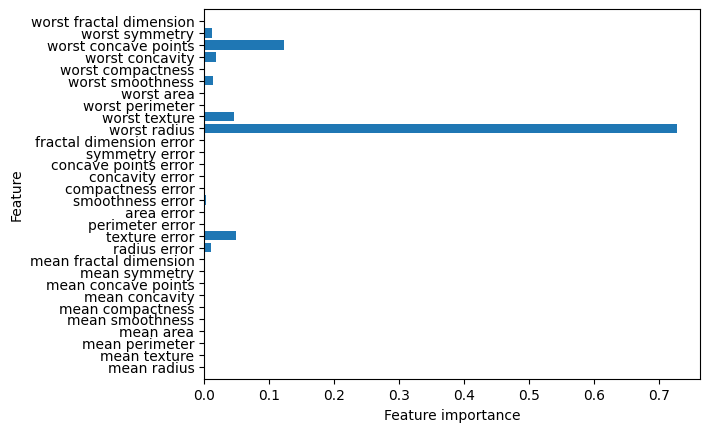

In [78]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(tree)

## 2.21 Ringkasan Decision Trees
**Kelebihan:**
- Mudah divisualisasikan dan dipahami oleh orang awam.
- Tidak memerlukan penskalaan data (scaling) seperti normalisasi.
- Bisa menangani fitur kategori maupun numerik secara bersamaan.

**Kekurangan:**
- Sangat mudah mengalami **Overfitting**, bahkan dengan pemangkasan (pruning).
- Cenderung memiliki stabilitas yang rendah (perubahan kecil pada data bisa mengubah struktur pohon secara drastis).

## 2.22 Ensembles of Decision Trees
Ensemble adalah metode yang menggabungkan beberapa model Machine Learning untuk menciptakan model yang lebih kuat. Dalam konteks pohon keputusan, ada dua jenis ensemble yang paling populer:
1. **Random Forests**
2. **Gradient Boosted Decision Trees (GBDT)**

## 2.23 Random Forests
Random Forest pada dasarnya adalah kumpulan dari banyak Decision Trees, di mana setiap pohon sedikit berbeda dari yang lain.

**Cara Kerja (Teori):**
- **Bootstrapping**: Mengambil sampel data secara acak untuk setiap pohon.
- **Random Feature Selection**: Saat membelah simpul, model hanya memilih dari subset fitur yang diacak.
- **Voting**: Prediksi akhir diambil berdasarkan suara terbanyak (klasifikasi) atau rata-rata (regresi) dari semua pohon.
- **Keuntungan**: Sangat kuat dalam mencegah **Overfitting** yang sering terjadi pada pohon tunggal.

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

# Membangun Random Forest dengan 100 pohon
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

print(f"Accuracy on training set: {forest.score(X_train, y_train):.3f}")
print(f"Accuracy on test set: {forest.score(X_test, y_test):.3f}")

Accuracy on training set: 1.000
Accuracy on test set: 0.958


## 2.24 Analisis Random Forest
Sama seperti pohon tunggal, Random Forest juga memberikan informasi tentang **Feature Importance**. Bedanya, hasil dari Random Forest biasanya lebih stabil dan mencakup lebih banyak fitur karena proses pengacakan yang dilakukan.

Text(0.5, 1.0, 'Feature Importance in Random Forest')

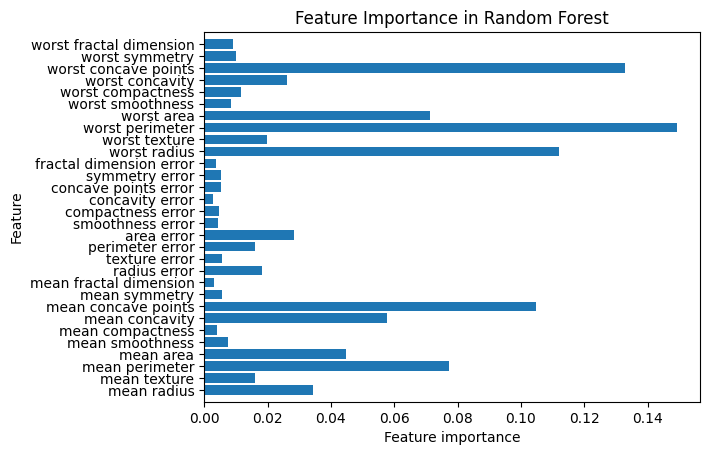

In [80]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(forest)
plt.title("Feature Importance in Random Forest")

## 2.25 Gradient Boosted Decision Trees (GBDT)
Berbeda dengan Random Forest yang membangun pohon secara mandiri, GBDT membangun pohon secara berurutan (*sequential*).

**Cara Kerja (Teori):**
- Setiap pohon baru mencoba memperbaiki kesalahan (error) yang dibuat oleh pohon sebelumnya.
- Menggunakan parameter **Learning Rate** untuk mengontrol seberapa kuat setiap pohon mencoba mengoreksi kesalahan sebelumnya.
- **Kekuatan**: Seringkali memberikan akurasi yang lebih tinggi daripada Random Forest jika parameternya diatur dengan tepat.
- **Kelemahan**: Lebih sensitif terhadap pengaturan parameter dan memerlukan waktu pelatihan yang lebih lama jika tidak hati-hati.

In [81]:
from sklearn.ensemble import GradientBoostingClassifier

# GBDT dengan pengaturan default
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)

print(f"Accuracy on training set (Default): {gbrt.score(X_train, y_train):.3f}")
print(f"Accuracy on test set (Default): {gbrt.score(X_test, y_test):.3f}")

# Mencegah overfitting dengan membatasi kedalaman pohon
gbrt_pruned = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt_pruned.fit(X_train, y_train)

print(f"\nAccuracy on training set (depth=1): {gbrt_pruned.score(X_train, y_train):.3f}")
print(f"Accuracy on test set (depth=1): {gbrt_pruned.score(X_test, y_test):.3f}")

Accuracy on training set (Default): 1.000
Accuracy on test set (Default): 0.958

Accuracy on training set (depth=1): 0.988
Accuracy on test set (depth=1): 0.958


## 2.26 Ringkasan Model Ensemble
**Kelebihan:**
- Merupakan algoritma paling kuat untuk data tabular (data berbentuk tabel).
- Bekerja sangat baik tanpa memerlukan banyak prapemrosesan data (seperti scaling).

**Kekurangan:**
- Model "Black Box": Lebih sulit untuk divisualisasikan dan dipahami secara detail dibandingkan satu pohon tunggal.
- Memerlukan lebih banyak memori dan daya komputasi.

## 2.27 Kernelized Support Vector Machines
Kernelized SVM adalah pengembangan dari model linear yang memungkinkan pembuatan batas keputusan yang jauh lebih kompleks daripada sekadar garis lurus.

**Konsep Utama:**
- Model linear seringkali gagal pada data yang tidak bisa dipisahkan secara linear.
- SVM mengatasi ini dengan memetakan data ke dimensi yang lebih tinggi di mana data tersebut menjadi bisa dipisahkan secara linear.

## 2.28 Mengapa Kita Butuh Fitur Non-linear?
Terkadang, fitur asli tidak cukup untuk memisahkan data. Menambahkan fitur baru (misalnya kuadrat dari fitur yang ada) bisa membantu model linear melihat pola yang sebelumnya tersembunyi.

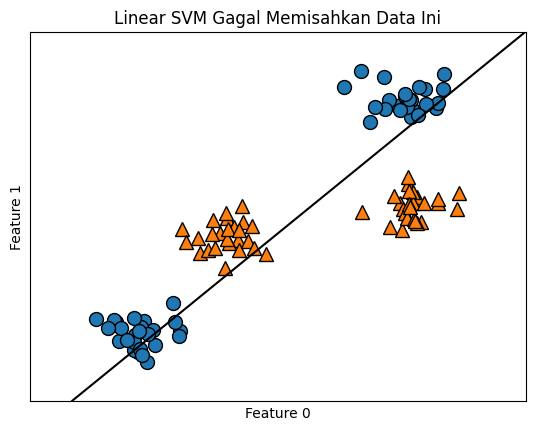

In [82]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC

X, y = make_blobs(centers=4, random_state=8)
y = y % 2

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

linear_svm = LinearSVC(max_iter=10000).fit(X, y)
mglearn.plots.plot_2d_separator(linear_svm, X)
plt.title("Linear SVM Gagal Memisahkan Data Ini")
plt.show()

## 2.29 The Kernel Trick dan RBF Kernel
Menambah fitur secara manual itu melelahkan. SVM punya "Kernel Trick" yang memungkinkan Saya menghitung hubungan data di dimensi tinggi tanpa harus benar-benar membuat fitur baru tersebut.

**RBF (Radial Basis Function) Kernel:**
Ini adalah kernel yang paling populer. Ia bekerja dengan mempertimbangkan jarak antar titik data. Prediksi dilakukan berdasarkan seberapa dekat sebuah data baru dengan titik-titik data penting yang disebut **Support Vectors**.

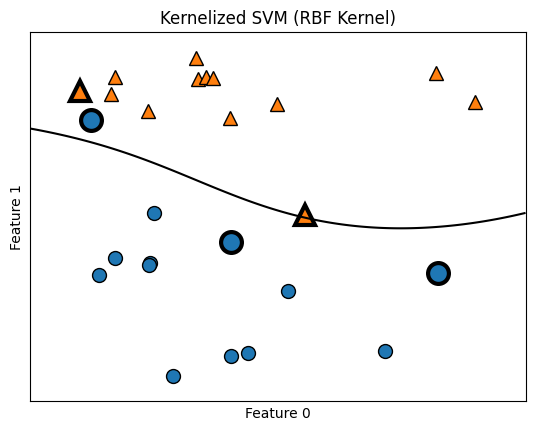

In [83]:
from sklearn.svm import SVC

X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)

mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)

sv = svm.support_vectors_
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Kernelized SVM (RBF Kernel)")
plt.show()

## 2.30 Memahami Parameter C dan Gamma
SVM memiliki dua "tombol" penting yang harus diatur:

1. **Gamma ($\gamma$)**: Mengontrol seberapa jauh pengaruh satu titik data tunggal.
   - **Gamma Kecil**: Pengaruhnya luas (garis batas sangat halus).
   - **Gamma Besar**: Pengaruhnya sempit (garis batas sangat berliku mengikuti titik data).
2. **C**: Parameter regularisasi (mirip dengan model linear).
   - **C Kecil**: Model sangat dibatasi (simpel).
   - **C Besar**: Model berusaha keras mengklasifikasikan setiap titik dengan benar (kompleks).

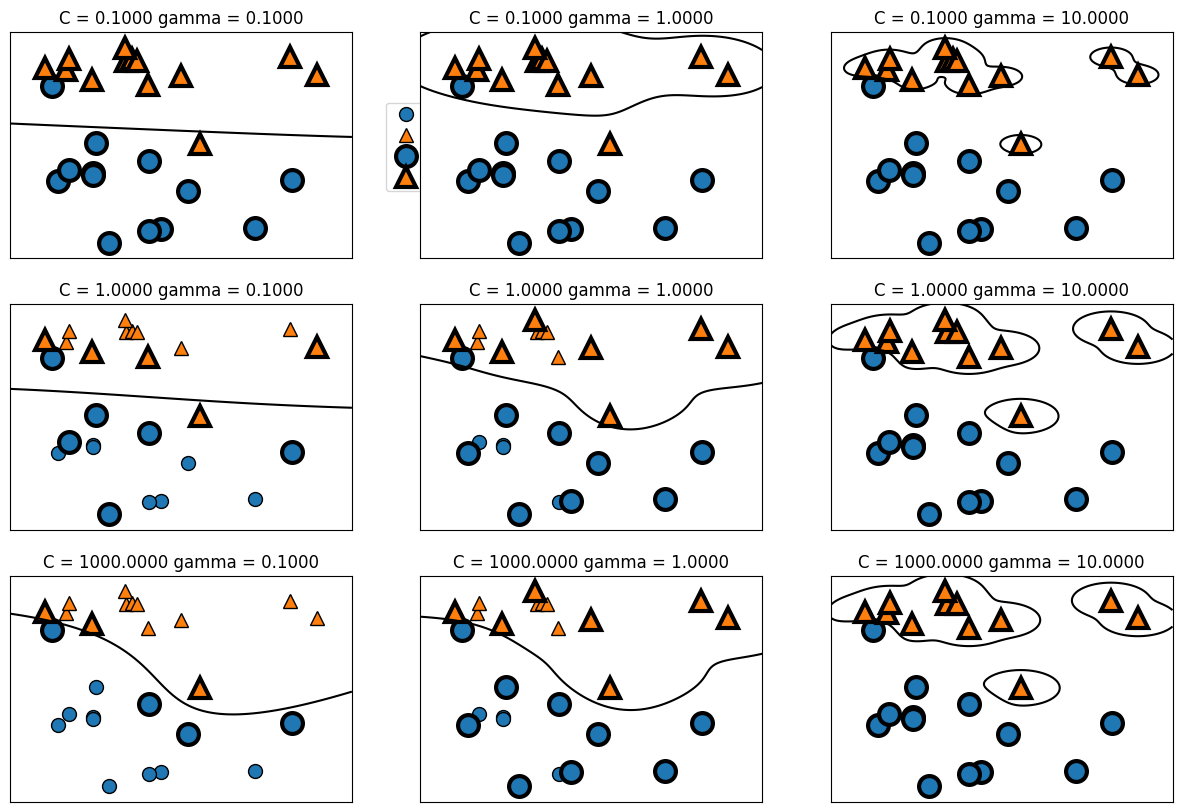

In [84]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)

axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],
                  loc=(1.1, 0.3))

## 2.31 Ringkasan SVM
**Kelebihan:**
- Sangat kuat dan bekerja dengan baik pada berbagai dataset.
- Bisa membuat batas keputusan yang sangat kompleks.

**Kelemahan:**
- Sangat sensitif terhadap penskalaan data (data harus di-scale dulu ke rentang 0-1).
- Sulit dipahami/diinterpretasikan hasilnya dibandingkan model linear atau pohon.
- Lambat jika jumlah datanya sudah mencapai ratusan ribu atau jutaan.

## 2.32 Neural Networks (Multilayer Perceptrons)
Multilayer Perceptrons (MLP) adalah algoritma yang terinspirasi dari cara kerja otak manusia. MLP bekerja dengan memproses input melalui lapisan-lapisan "neuron" yang tersembunyi untuk menghasilkan prediksi.

**Konsep Utama:**
- **Input Layer**: Fitur-fitur awal dari data Saya.
- **Hidden Layers**: Lapisan perantara di mana model mempelajari pola rumit.
- **Activation Function**: Fungsi (seperti ReLU atau tanh) yang menentukan apakah sebuah "neuron" harus aktif atau tidak.
- **Weights**: Bobot yang dipelajari model untuk menentukan pentingnya suatu koneksi antar neuron.

## 2.33 Implementasi MLPClassifier
Saya mencoba menggunakan `MLPClassifier` dari library `scikit-learn` pada dataset kanker payudara. Perlu diingat bahwa secara default, MLP menggunakan 100 hidden nodes, yang mungkin terlalu banyak untuk dataset kecil ini.

In [85]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)

print(f"Accuracy on training set: {mlp.score(X_train, y_train):.2f}")
print(f"Accuracy on test set: {mlp.score(X_test, y_test):.2f}")

Accuracy on training set: 0.94
Accuracy on test set: 0.92


## 2.34 Pentingnya Penskalaan Data (Scaling)
Sama seperti SVM, Neural Networks sangat sensitif terhadap rentang nilai fitur. Jika satu fitur punya nilai 0-1 dan fitur lain punya nilai 0-1000, model akan kesulitan belajar.

**Solusi:**
Saya mengubah semua fitur agar memiliki rata-rata 0 dan varians 1 menggunakan `StandardScaler`.

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

print(f"Accuracy on training set (after scaling): {mlp.score(X_train_scaled, y_train):.3f}")
print(f"Accuracy on test set (after scaling): {mlp.score(X_test_scaled, y_test):.3f}")

Accuracy on training set (after scaling): 0.998
Accuracy on test set (after scaling): 0.965


## 2.35 Ringkasan Akhir Chapter 2
Setelah mempelajari berbagai algoritma Supervised Learning, berikut panduan singkat pemilihannya:

1. **Dataset Kecil/Simpel**: Gunakan **k-NN** atau **Linear Models**.
2. **Data Tabular/Tabel**: Gunakan **Random Forests** atau **Gradient Boosting** (paling populer).
3. **Data Sangat Besar/Kompleks (Citra, Suara)**: Gunakan **Neural Networks**.
4. **Data dengan Fitur Banyak**: Gunakan **Lasso** atau **Linear SVM**.

# Chapter 3: Unsupervised Learning and Preprocessing
Unsupervised Learning adalah tipe Machine Learning di mana kita hanya memberikan model data input tanpa memberikan jawaban atau targetnya (label). Tujuannya adalah agar model menemukan pola tersembunyi, struktur, atau representasi baru dari data tersebut secara mandiri.



### Dua Tipe Utama:
1. **Unsupervised Transformations**: Mengubah representasi data agar lebih sederhana, menghilangkan *noise*, atau memudahkan visualisasi (misal: *Scaling* dan *Dimensionality Reduction*).
2. **Clustering (Pengelompokan)**: Membagi data ke dalam kelompok-kelompok yang memiliki kemiripan secara otomatis tanpa mengetahui label kelasnya sebelumnya (misal: K-Means).



### Konsep Penting:
- **Preprocessing & Scaling**: Proses menyamakan rentang nilai antar fitur agar model tidak didominasi oleh fitur dengan angka besar.
- **Dimensionality Reduction**: Mengurangi jumlah fitur untuk menyederhanakan data namun tetap mempertahankan informasi penting.
- **Evaluation Challenge**: Tantangan di mana kita sulit menilai apakah hasil model sudah "benar" karena tidak adanya label pembanding (*ground truth*).

## 3.2 Tantangan dalam Unsupervised Learning
Tantangan terbesar yang saya temukan dalam *Unsupervised Learning* adalah sulitnya mengevaluasi apakah algoritma telah mempelajari sesuatu yang berguna. Karena tidak memiliki label atau target keluaran, saya tidak bisa memvalidasi hasil prediksi secara otomatis seperti pada *Supervised Learning*. Seringkali, cara terbaik untuk mengevaluasi hasil model adalah melalui inspeksi visual secara manual.

## 3.3 Preprocessing dan Scaling
Banyak algoritma Machine Learning sangat sensitif terhadap skala data yang digunakan. Oleh karena itu, saya menerapkan beberapa teknik penskalaan untuk memastikan semua fitur berada dalam rentang nilai yang serupa. Saya menggunakan empat jenis penskalaan utama: `StandardScaler`, `MinMaxScaler`, `RobustScaler`, dan `Normalizer`.

## 3.4 Menerapkan Transformasi Data
Saya menggunakan dataset *Breast Cancer* untuk mendemonstrasikan cara melakukan transformasi data menggunakan `MinMaxScaler`. Proses ini melibatkan pemisahan data, pelatihan *scaler* pada data *training*, dan transformasi pada data *training* maupun *test*.

In [87]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.min(axis=0))
print(X_train_scaled.max(axis=0))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


## 3.5 Penskalaan Konsisten pada Data Training dan Test
Sangat penting bagi saya untuk memastikan bahwa data *test* diskalakan menggunakan parameter yang sama dengan data *training*. Jika saya menggunakan parameter yang berbeda untuk masing-masing kumpulan data, maka hubungan antar fitur akan rusak. Pada bagian ini, saya memvisualisasikan perbedaan antara penskalaan yang benar dan yang salah untuk memahami dampaknya pada distribusi data.

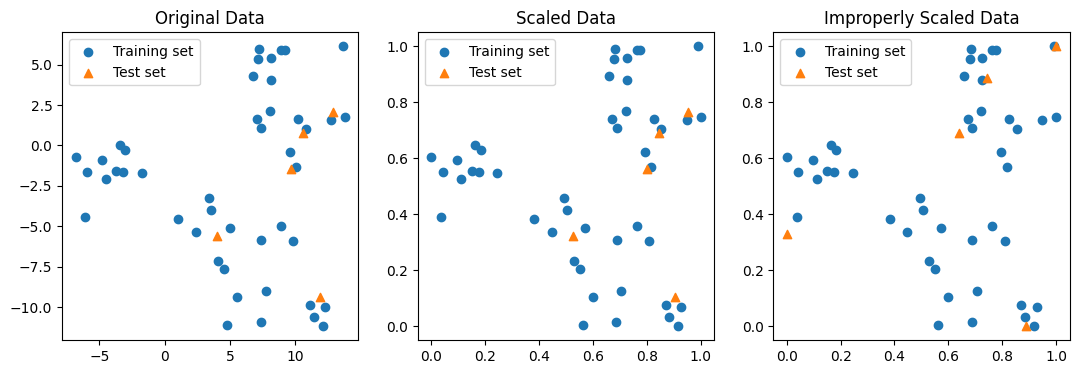

In [88]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
X_train, X_test = train_test_split(X, random_state=5, test_size=.1)

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].scatter(X_train[:, 0], X_train[:, 1], label="Training set")
axes[0].scatter(X_test[:, 0], X_test[:, 1], marker='^', label="Test set")
axes[0].set_title("Original Data")
axes[0].legend(loc='upper left')

axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], label="Training set")
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker='^', label="Test set")
axes[1].set_title("Scaled Data")
axes[1].legend(loc='upper left')

scaler_bad = MinMaxScaler()
scaler_bad.fit(X_test)
X_test_scaled_bad = scaler_bad.transform(X_test)
axes[2].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], label="Training set")
axes[2].scatter(X_test_scaled_bad[:, 0], X_test_scaled_bad[:, 1], marker='^', label="Test set")
axes[2].set_title("Improperly Scaled Data")
axes[2].legend(loc='upper left')

plt.show()

## 3.6 Dampak Preprocessing pada Performa Model
Setelah memahami berbagai teknik penskalaan, saya ingin melihat bagaimana pengaruhnya terhadap performa model Supervised Learning. Saya akan membandingkan akurasi model `SVC` (Support Vector Classifier) saat menggunakan data asli dibandingkan dengan data yang telah saya skala menggunakan `MinMaxScaler`. Hal ini penting bagi saya untuk membuktikan bahwa prapemrosesan yang tepat dapat meningkatkan akurasi model secara signifikan.

In [89]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

svm = SVC(C=100)
svm.fit(X_train, y_train)
print(svm.score(X_test, y_test))

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print(svm.score(X_test_scaled, y_test))

0.9440559440559441
0.965034965034965


## 3.7 Principal Component Analysis (PCA)
PCA adalah teknik yang saya gunakan untuk mereduksi jumlah dimensi dalam dataset dengan tetap mempertahankan informasi sebanyak mungkin. Teknik ini sangat berguna ketika saya berhadapan dengan data yang memiliki terlalu banyak fitur sehingga sulit untuk divisualisasikan. Saya akan memetakan data *Breast Cancer* yang memiliki 30 fitur menjadi hanya 2 komponen utama saja.

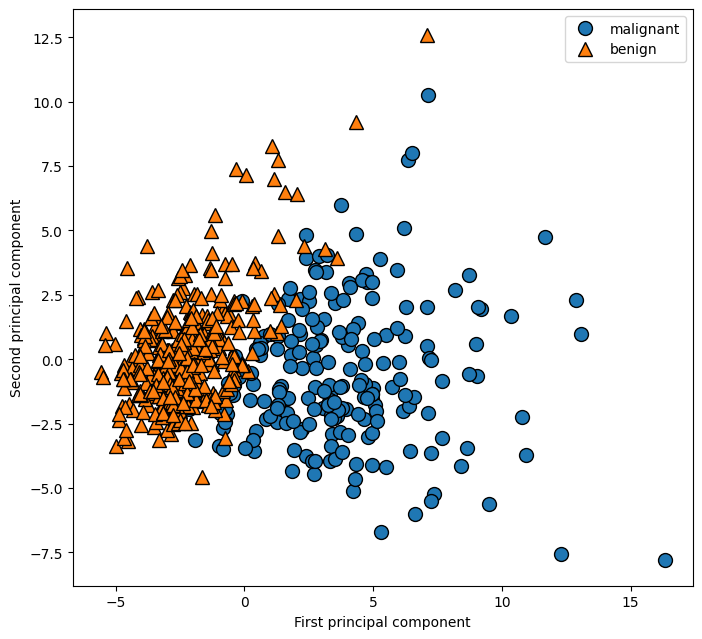

In [90]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mglearn
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

plt.figure(figsize=(8, 8))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)
plt.legend(cancer.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.show()

## 3.8 Analisis Komponen PCA
Setelah melakukan reduksi dimensi, saya ingin melihat fitur mana saja yang paling berpengaruh terhadap pembentukan dua komponen utama tersebut. Dengan menggunakan atribut `components_`, saya bisa membuat peta panas (heatmap) untuk melihat kontribusi setiap fitur asli terhadap komponen utama yang baru dibuat.

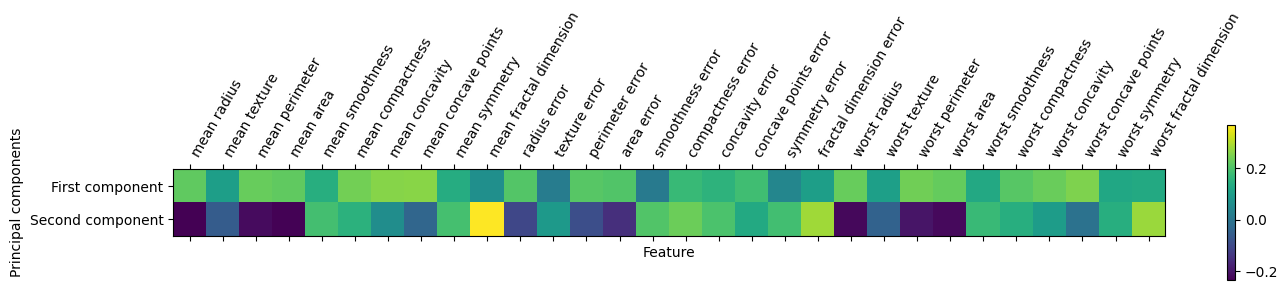

In [91]:
import numpy as np

plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)), cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")
plt.show()

## 3.9 Non-negative Matrix Factorization (NMF)
Saya menggunakan Non-negative Matrix Factorization (NMF) sebagai teknik alternatif untuk reduksi dimensi. Berbeda dengan PCA yang mencoba mencari arah dengan varians terbesar, NMF bertujuan untuk mengekstraksi fitur yang lebih mudah diinterpretasikan karena ia hanya bekerja pada data non-negatif. Teknik ini sangat berguna ketika saya ingin menguraikan data menjadi komponen-komponen yang bersifat aditif.

In [92]:
from sklearn.decomposition import NMF
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

nmf = NMF(n_components=15, random_state=0, max_iter=2000)
nmf.fit(X_train_scaled)
X_train_nmf = nmf.transform(X_train_scaled)

print(X_train_nmf.shape)

(426, 15)


## 3.10 Manifold Learning dengan t-SNE
Saya menerapkan t-SNE (*t-distributed Stochastic Neighbor Embedding*) untuk memvisualisasikan dataset yang memiliki dimensi tinggi. t-SNE adalah algoritma manifold learning yang sangat efektif untuk mempertahankan struktur lokal data. Saya akan menggunakan dataset digit tulisan tangan untuk melihat bagaimana t-SNE mengelompokkan data yang mirip dalam ruang dua dimensi.

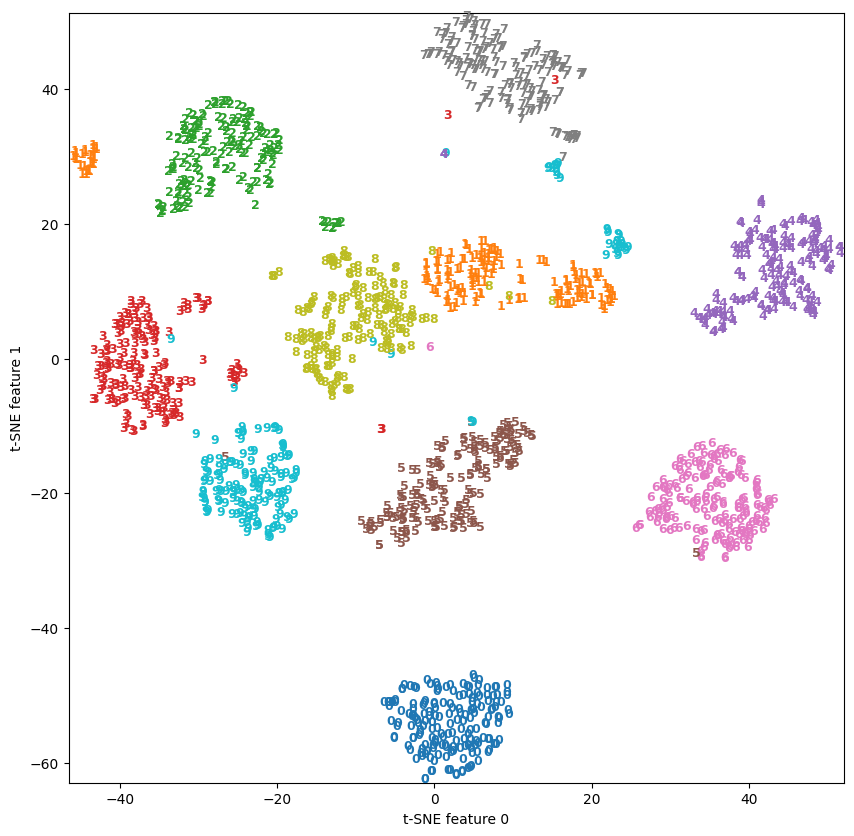

In [93]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

digits = load_digits()
tsne = TSNE(random_state=42)
digits_tsne = tsne.fit_transform(digits.data)

plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max() + 1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max() + 1)

for i in range(len(digits.data)):
    plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),
             color = plt.cm.tab10(digits.target[i] / 10.),
             fontdict={'weight': 'bold', 'size': 9})

plt.xlabel("t-SNE feature 0")
plt.ylabel("t-SNE feature 1")
plt.show()

## 3.11 Clustering: K-Means
Saya mulai mengeksplorasi teknik *Clustering* menggunakan algoritma K-Means. K-Means bekerja dengan membagi data ke dalam sejumlah kelompok yang sudah saya tentukan sebelumnya. Algoritma ini akan mencari pusat kelompok (centroid) dan menetapkan setiap titik data ke centroid terdekat untuk meminimalkan jarak di dalam kelompok tersebut.

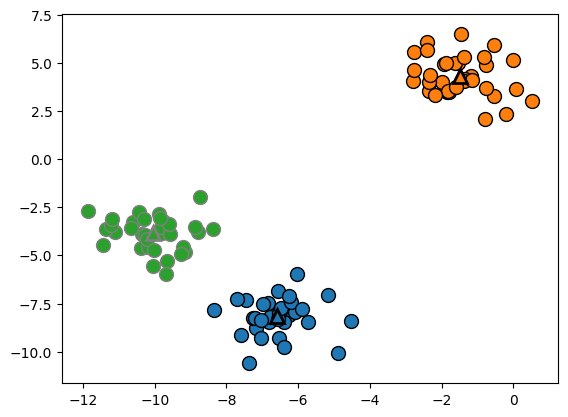

In [94]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import mglearn

X, y = make_blobs(random_state=1)
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers='^', markeredgewidth=2)
plt.show()

## 3.12 Keterbatasan K-Means
Saya mendemonstrasikan situasi di mana K-Means mungkin gagal memberikan hasil yang optimal. K-Means mengasumsikan bahwa setiap cluster memiliki bentuk yang bulat dan ukuran yang seragam. Saya akan menguji performa algoritma ini pada dataset dengan bentuk yang tidak bulat untuk melihat batasan fungsionalnya.

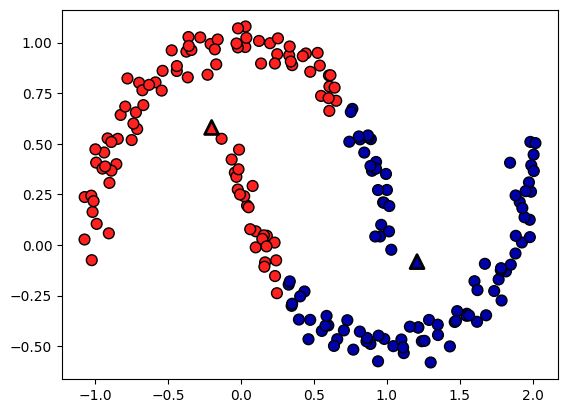

In [95]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)
kmeans = KMeans(n_clusters=2, n_init='auto')
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap=mglearn.cm2, s=60, edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='^', c=[mglearn.cm2(0), mglearn.cm2(1)], s=100, linewidth=2, edgecolors='k')
plt.show()

## 3.13 Agglomerative Clustering
Saya menggunakan *Agglomerative Clustering* untuk membangun hierarki kelompok data. Algoritma ini bekerja dengan cara menetapkan setiap titik data sebagai kluster tersendiri, kemudian secara berulang menggabungkan pasangan kluster terdekat hingga jumlah kluster yang diinginkan tercapai. Keuntungan utama dari metode ini adalah kemampuannya untuk menghasilkan dendrogram yang memvisualisasikan hubungan hierarkis antar data.

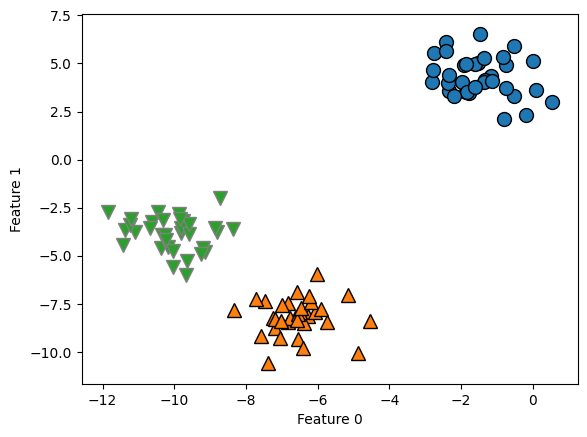

In [96]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
import mglearn
import matplotlib.pyplot as plt

X, y = make_blobs(random_state=1)

agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)

mglearn.discrete_scatter(X[:, 0], X[:, 1], assignment)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

## 3.14 DBSCAN
Saya menggunakan DBSCAN untuk mengelompokkan data berdasarkan tingkat kepadatannya. Algoritma ini sangat efektif karena tidak mengharuskan saya untuk menentukan jumlah kluster di awal dan mampu mendeteksi titik data yang dianggap sebagai gangguan (*noise*). DBSCAN bekerja dengan cara mengidentifikasi titik-titik yang berada di area padat dan menggabungkannya menjadi satu kelompok, sementara titik di area yang jarang akan ditandai sebagai pencilan.

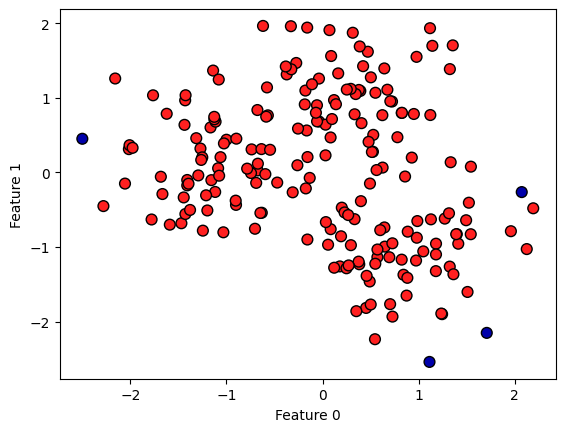

In [97]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X, y = make_blobs(random_state=0, n_samples=200)

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap=mglearn.cm2, s=60, edgecolors='black')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

## 3.15 Evaluasi dan Perbandingan Algoritma Clustering
Saya menggunakan metrik evaluasi seperti *Adjusted Rand Index* (ARI) untuk membandingkan hasil pengelompokan dengan label asli guna mengukur akurasi algoritma. Namun, karena dalam kondisi nyata label seringkali tidak tersedia, saya juga menggunakan skor siluet untuk menilai seberapa baik pemisahan antar kelompok berdasarkan kepadatan dan jarak. Perbandingan ini membantu saya memilih algoritma yang paling sesuai dengan karakteristik distribusi data yang saya hadapi.

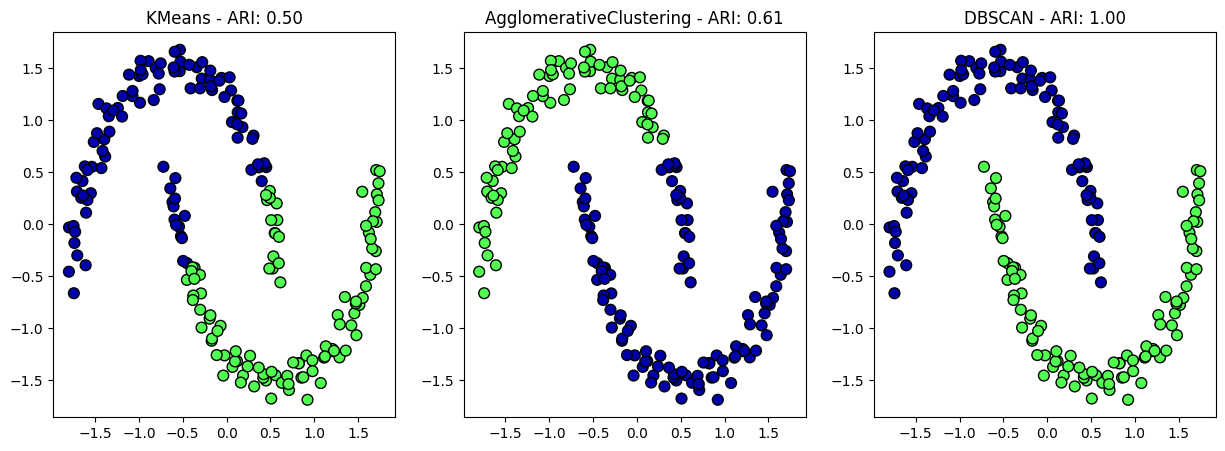

In [98]:
from sklearn.metrics.cluster import adjusted_rand_score
import numpy as np

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

algorithms = [KMeans(n_clusters=2, n_init='auto'), AgglomerativeClustering(n_clusters=2), DBSCAN()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, algorithm in zip(axes, algorithms):
    clusters = algorithm.fit_predict(X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap=mglearn.cm3, s=60, edgecolors='black')
    ax.set_title(f"{algorithm.__class__.__name__} - ARI: {adjusted_rand_score(y, clusters):.2f}")

plt.show()

## 3.16 Ringkasan dan Kesimpulan Chapter 3
Melalui bab ini, saya telah mempelajari berbagai teknik penting dalam *Unsupervised Learning* dan *Preprocessing*. Saya memahami bahwa penskalaan data merupakan langkah krusial sebelum menerapkan algoritma untuk memastikan stabilitas model. Selain itu, saya telah mengeksplorasi metode reduksi dimensi untuk penyederhanaan data serta teknik pengelompokan untuk menemukan pola tersembunyi tanpa bantuan label. Pemahaman ini menjadi fondasi bagi saya untuk mengolah data mentah menjadi informasi yang lebih bermakna.